<a href="https://colab.research.google.com/github/Sank3t-Pand3y/MyPractiseML/blob/main/K_Means_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples = 1000, centers = 3, n_features=2, random_state = 23)

In [4]:
X.shape

(1000, 2)

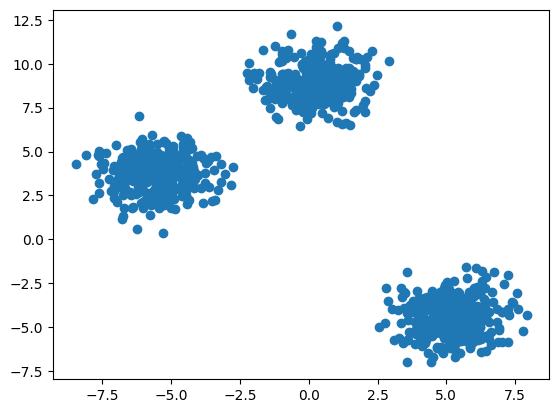

In [5]:
plt.scatter(X[:,0], X[:,1])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=42)

In [9]:
# How to Find the value of K

from sklearn.cluster import KMeans

In [10]:
## Manual Process
## Elbow Method to select the K value


wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [11]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1172.108942690815,
 1033.1119243414655,
 855.6538308658791,
 805.7892227204809,
 679.0187215473877,
 582.8325616824895,
 546.961047480286]

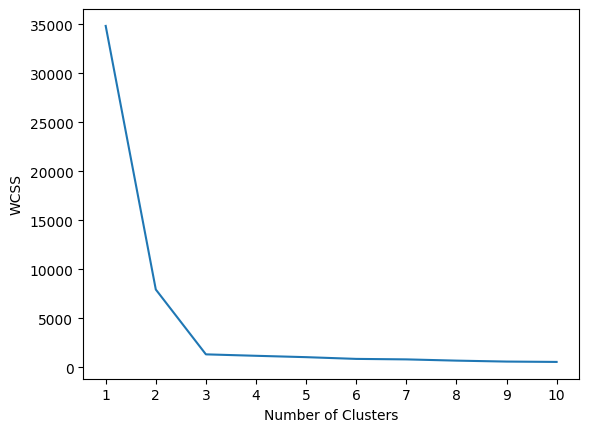

In [12]:
## Plot the elbow curve
plt.plot(range(1, 11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
# From above figure, we found that we need k=3

In [14]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [15]:
y_labels = kmeans.fit_predict(X_train)

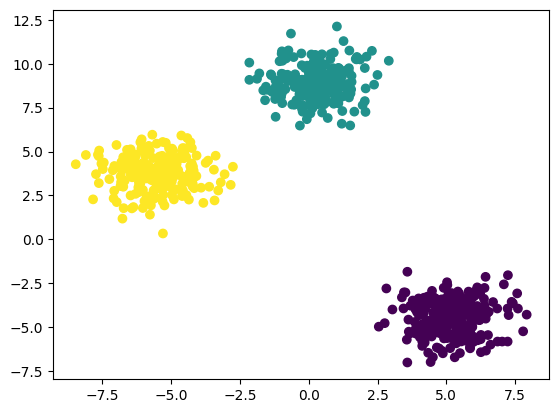

In [16]:
plt.scatter(X_train[:,0],X_train[:,1], c = y_labels)

In [17]:
y_test_labels = kmeans.predict(X_test)

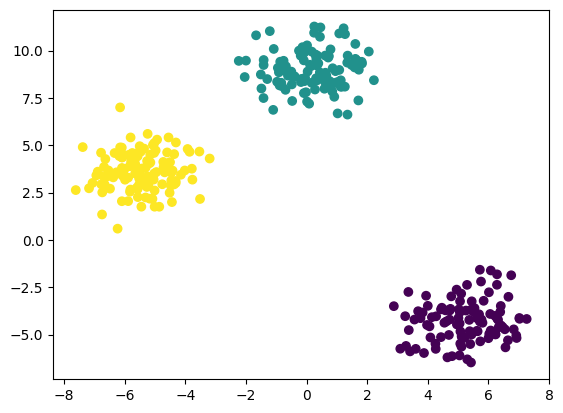

In [18]:
plt.scatter(X_test[:,0], X_test[:,1], c = y_test_labels)

In [19]:
## Now we go for Automatic Process to Find the value of K
## knee loactor to do Automated Process

!pip install kneed

In [20]:
from kneed import KneeLocator

In [21]:
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
kl.elbow

np.int64(3)

In [22]:
## Performance metrics
## Silhouttee score

from sklearn.metrics import silhouette_score

In [23]:
silhouette_coefficients = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train)
  score = silhouette_score(X_train, kmeans.labels_)
  silhouette_coefficients.append(score)

In [24]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6469713919781352),
 np.float64(0.6324388543217302),
 np.float64(0.4873748371786202),
 np.float64(0.34205712371510444),
 np.float64(0.3305441903583322),
 np.float64(0.33188243476668516),
 np.float64(0.34009738175739385)]

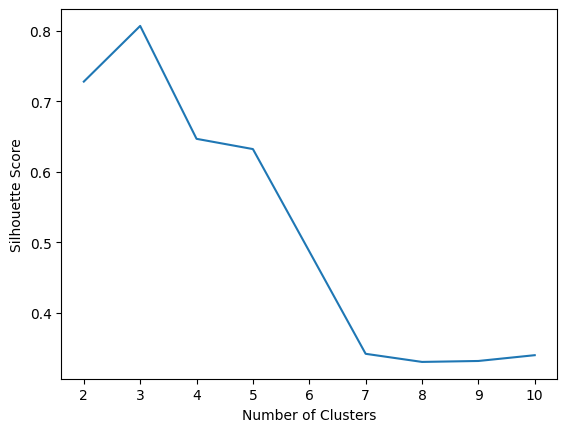

In [25]:
## Plotting Silhouette Score

plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()